# 01 · Data Overview and EDA

**Goal:** understand the sample structure before any modelling.
1. How volume and bad rate evolve over the 92 weeks (`WEEK_NUM`) — the competition metric is computed week by week.
2. How large each source table is. The largest credit-bureau table has ~190M rows, so memory-aware processing is required.

All reading is lazy (`polars.scan_parquet`); nothing is loaded until `collect()`.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().resolve()
ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import polars as pl
import psutil

from hcrisk.config import RAW_DIR, check_data, savefig
from hcrisk.io import scan, table_exists

check_data()
print(f"Polars {pl.__version__} | available RAM {psutil.virtual_memory().available / 1e9:.1f} GB")
print(sorted(p.name for p in RAW_DIR.glob("*.parquet")))

Polars 1.44.2 | available RAM 7.3 GB
['train_applprev_1_0.parquet', 'train_applprev_1_1.parquet', 'train_applprev_2.parquet', 'train_base.parquet', 'train_credit_bureau_a_1_0.parquet', 'train_credit_bureau_a_1_1.parquet', 'train_credit_bureau_a_1_2.parquet', 'train_credit_bureau_a_1_3.parquet', 'train_credit_bureau_a_2_0.parquet', 'train_credit_bureau_a_2_1.parquet', 'train_credit_bureau_a_2_10.parquet', 'train_credit_bureau_a_2_2.parquet', 'train_credit_bureau_a_2_3.parquet', 'train_credit_bureau_a_2_4.parquet', 'train_credit_bureau_a_2_5.parquet', 'train_credit_bureau_a_2_6.parquet', 'train_credit_bureau_a_2_7.parquet', 'train_credit_bureau_a_2_8.parquet', 'train_credit_bureau_a_2_9.parquet', 'train_credit_bureau_b_1.parquet', 'train_credit_bureau_b_2.parquet', 'train_debitcard_1.parquet', 'train_deposit_1.parquet', 'train_other_1.parquet', 'train_person_1.parquet', 'train_person_2.parquet', 'train_static_0_0.parquet', 'train_static_0_1.parquet', 'train_static_cb_0.parquet', 'train_t

## 1. Volume and bad rate by week

(1526659, 5) | overall bad rate: 0.0314 | decision dates: 2019-01-01 -> 2020-10-05


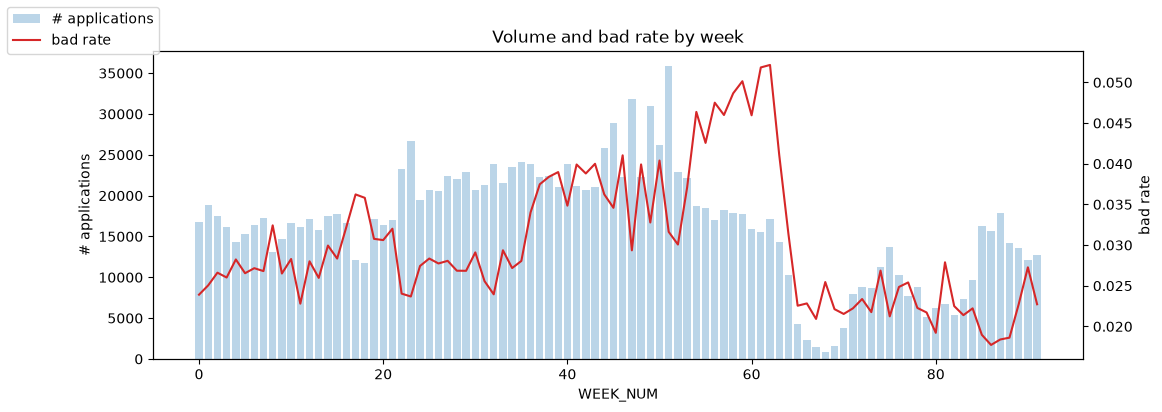

In [2]:
base = scan("base").collect()
print(base.shape, "| overall bad rate:", round(base["target"].mean(), 4),
      "| decision dates:", base["date_decision"].min(), "->", base["date_decision"].max())

weekly = (base.group_by("WEEK_NUM")
              .agg(pl.len().alias("n"), pl.col("target").mean().alias("bad_rate"))
              .sort("WEEK_NUM"))

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.bar(weekly["WEEK_NUM"], weekly["n"], alpha=0.3, label="# applications")
ax1.set_xlabel("WEEK_NUM"); ax1.set_ylabel("# applications")
ax2 = ax1.twinx()
ax2.plot(weekly["WEEK_NUM"], weekly["bad_rate"], color="C3", label="bad rate")
ax2.set_ylabel("bad rate")
fig.legend(loc="upper left"); ax1.set_title("Volume and bad rate by week")
savefig(fig, "01_weekly_volume_badrate"); plt.show()

**What to look for (full data):** the bad rate is ~2.5–3% through week 40, rises to >5% by week 62, and drops
back to ~2% after a volume collapse at week ~63 (around the COVID-19 lockdowns). This structural break is the
reason for the time-based sample design used from notebook 03 onwards.

## 2. Table sizes (lazy row counts)

In [3]:
TABLES = ["static_0", "static_cb_0", "applprev_1", "credit_bureau_a_1", "credit_bureau_b_1", "person_1",
          "deposit_1", "debitcard_1", "other_1", "tax_registry_a_1", "tax_registry_b_1", "tax_registry_c_1",
          "applprev_2", "credit_bureau_a_2", "credit_bureau_b_2", "person_2"]
rows = []
for t in TABLES:
    if not table_exists(t):
        continue
    lf = scan(t)
    rows.append({"table": t, "rows": lf.select(pl.len()).collect().item(), "columns": len(lf.collect_schema())})
pl.DataFrame(rows)

table,rows,columns
str,i64,i64
"""static_0""",1526659,168
"""static_cb_0""",1500476,53
"""applprev_1""",6525979,41
"""credit_bureau_a_1""",15940537,79
"""credit_bureau_b_1""",85791,45
…,…,…
"""tax_registry_c_1""",3343800,5
"""applprev_2""",14075487,6
"""credit_bureau_a_2""",188298452,19
